In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import random
import math
import matplotlib.pyplot as plt
from pyomo.environ import *
from optimization_utils import *
from param_loader import METANET_Params
from simulation_utils import *

In [3]:
# print ipopt version
!ipopt --version

Ipopt 3.14.16 (Darwin x86_64), ASL(20160307)


In [35]:
# rho_hat = df["Density"]
# q_hat = df["Flow"]
# print(max(q_hat))
# C_i = np.mean(sorted(q_hat)[-5:])
# print("C_i", C_i)
# K = len(rho_hat)

real_data = True

if real_data:
    q_hat = np.load("data/i35_sb2_flow_10sec_400m_1hr.npy")[1000:, :]
    # print(np.max(q_hat))
    rho_hat = np.load("data/i35_sb2_density_10sec_400m_1hr.npy")[1000:, :]
else:
    q_hat = np.load("data/q_synthetic.npy") #np.load("data/flow_10sec_400m_1hr.npy")
    # print(np.max(q_hat))
    rho_hat = np.load("data/p_synthetic.npy") #np.load("data/density_10sec_400m_1hr.npy")

v_hat = q_hat / rho_hat
print(rho_hat.shape)
flattened_q_hat = q_hat.flatten()
print(max(flattened_q_hat))
flattened_rho_hat = rho_hat.flatten()
C_i = np.mean(np.sort(flattened_q_hat)[-5:])
print("C_i", C_i)
K = len(flattened_rho_hat)
print("K", K)

(1880, 25)
4536.0
C_i 4536.0
K 47000


In [36]:
rho_hat = np.where(rho_hat == 0.0, 1e-3, rho_hat)
q_hat = np.where(q_hat == 0.0, 1e-3, q_hat)

In [37]:
if not real_data:
    print(rho_hat.shape)
    print(q_hat.shape)
    downstream_density = np.full(rho_hat.shape[0], 0)
    data_inflow = np.array([5500 if i in range(20, 20 + 90) else 4000 for i in range(rho_hat.shape[0])])

    np.save("data/downstream_density_synthetic.npy", downstream_density)
    np.save("data/inflow_synthetic.npy", data_inflow)


    plt.figure(figsize=(12, 6))
    # plt.subplot(2, 1, 1)
    # plt.plot(rho_hat[:, 0], label="Density")
    plt.plot(downstream_density, label="Downstream Density")
    plt.legend()
    plt.subplot(2, 1, 2)
    # plt.plot(q_hat[:, 0], label="Flow")
    plt.plot(data_inflow, label="Upstream Inflow")
    plt.legend()
    plt.show()


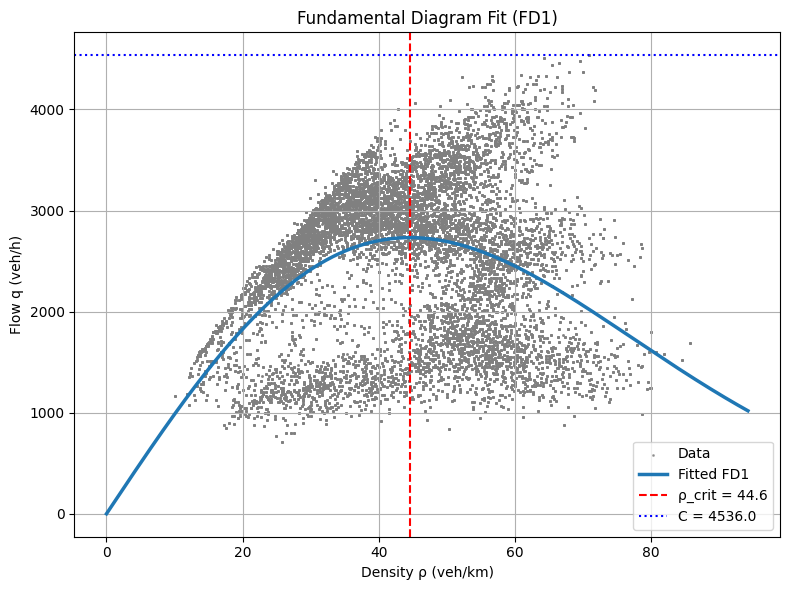

{'rho_crit': 44.56880201065253, 'V_free': 101.03308424870623, 'a': 2.0013075786620043, 'C': np.float64(4536.0), 'Q_fd1': <function fit_fd1.<locals>.Q_fd1 at 0x1318b7950>}


In [38]:
params = fit_fd1(flattened_rho_hat, flattened_q_hat)
print(params)

In [39]:
print(f"Bounds on rho: {np.min(rho_hat)} to {np.max(rho_hat)}")
print(f"Bounds on q: {np.min(q_hat)} to {np.max(q_hat)}")
print(f"Bounds on v: {np.min(v_hat)} to {np.max(v_hat)}")

Bounds on rho: 10.111962468139524 to 85.63710064759843
Bounds on q: 708.0 to 4536.0
Bounds on v: 12.523305523437498 to 117.34288869531251


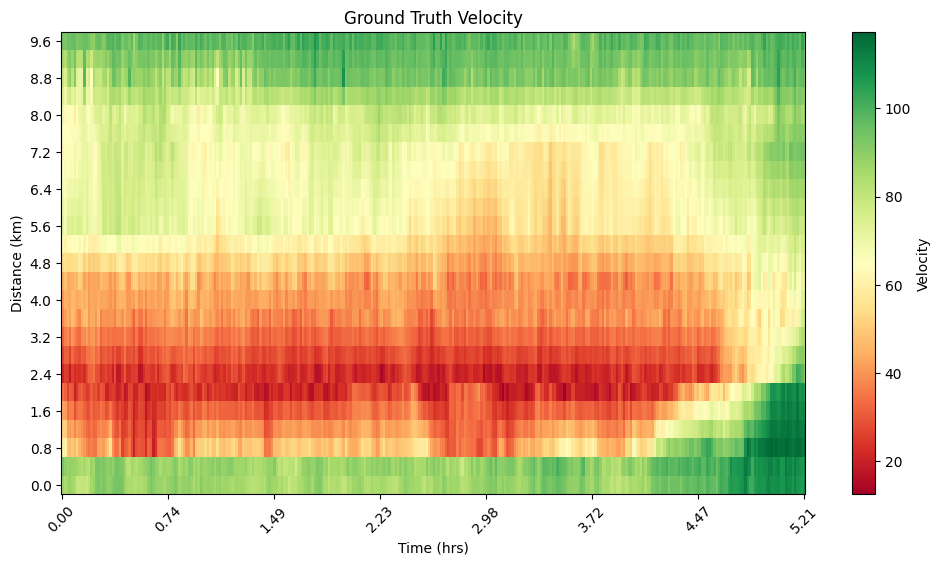

In [40]:
# plot v_hat
plt.figure(figsize=(12, 6))
plt.imshow(v_hat.T, aspect="auto", origin="lower", cmap="RdYlGn", interpolation="none")
plt.colorbar(label="Velocity")
# plt.gca().invert_yaxis()

#Convert time steps to hours
time_steps = v_hat.shape[0]
time_labels = [f"{(i * 10) / 3600:.2f}" for i in range(0, time_steps, int(time_steps / 7))]
time_ticks = list(range(0, time_steps, int(time_steps / 7)))

# Convert space steps to km
space_steps = v_hat.shape[1]
space_labels = [f"{(i * 400) / 1000:.1f}" for i in range(0, space_steps, int(space_steps / 10))]
space_ticks = list(range(0, space_steps, int(space_steps / 10)))

plt.xticks(time_ticks, time_labels, rotation=45)
plt.yticks(space_ticks, space_labels)   

plt.title("Ground Truth Velocity")
plt.xlabel("Time (hrs)")
plt.ylabel("Distance (km)")
plt.show()

In [41]:
print(v_hat.shape)

(1880, 25)


In [42]:
random.seed(1)
np.random.seed(1)

T = 10 / 3600
l = 0.4
num_calibrated_segments = v_hat.shape[1] - 2
include_ramping = False
varylanes = False
# lane_mapping = np.array([4 if i < num_calibrated_segments - 4 else 2 for i in range(num_calibrated_segments)])
RESULTS_DIR = "calibration_results/synthetic_test" if not real_data else "calibration_results_i35/test_sb2"
# boundary_conditions = {
#     "initial_flow": data_inflow,
#     "downstream_density": downstream_density,
# }

results = run_calibration(
    rho_hat,
    q_hat,
    T,
    l,
    num_calibrated_segments=num_calibrated_segments,
    # sep_boundary_conditions=boundary_conditions,
    varylanes=varylanes,
    # lane_mapping={i: 4 if i<10 else 2 for i in range(num_calibrated_segments)},#{0:4, 1:4, 2:4, 3:4.5, 4:5, 5:5, 6:5, 7:5, 8:5, 9:4, 10:4, 11:4, 12:4.5, 13:4},
    include_ramping=include_ramping,
    smoothing=True,
    constraint_tol=1e-12,
    enforce_ramps=False,
)

Ipopt 3.14.16: max_iter=20000
acceptable_constr_viol_tol=1e-12
constr_viol_tol=1e-12


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.16, running with linear solver MUMPS 5.6.2.

Number of nonzeros in equality constraint Jacobian...:   684002
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:   682468

Total number of variables............................:   129858
                     variables with only lower bounds:        0
                variables with lower and upper bounds:   129858
                     variables with only upper bounds:        0
Total 

In [43]:
# Save initial and downstream conditions
import os
if not os.path.exists(RESULTS_DIR):
    os.makedirs(RESULTS_DIR)
np.save(f"{RESULTS_DIR}/upstream_flow.npy", q_hat[:, 0])
np.save(f"{RESULTS_DIR}/downstream_density.npy", rho_hat[:, -1])

In [44]:
tau_array = results["tau"]
K_array = results["K"]
eta_high_array = results["eta_high"]
rho_crit_array = results["rho_crit"]
v_free_array = results["v_free"]
a_array = results["a"]
num_lanes_array = results["num_lanes"]
# if include_ramping:
    # gamma_array = results["gamma"]
beta_array = results["beta"]
r_inflow_array = results["r_inflow"]

In [45]:
# r_array = np.zeros(num_calibrated_segments)
# beta_array = np.zeros(num_calibrated_segments)
# print(beta_array.shape)
# print(r_inflow_array.shape)

In [46]:
# Save everything
tau_array = results["tau"]
K_array = results["K"]
eta_high_array = results["eta_high"]
rho_crit_array = results["rho_crit"]
v_free_array = results["v_free"]
a_array = results["a"]
num_lanes_array = results["num_lanes"]
# if include_ramping:
    # gamma_array = results["gamma"]
beta_array = results["beta"]
r_inflow_array = results["r_inflow"]
v_pred_array = results["v_pred"]
rho_pred_array = results["rho_pred"]
q_array = v_pred_array * rho_pred_array

np.save(f"{RESULTS_DIR}/tau.npy", tau_array)
np.save(f"{RESULTS_DIR}/K.npy", K_array)
np.save(f"{RESULTS_DIR}/eta_high.npy", eta_high_array)
np.save(f"{RESULTS_DIR}/rho_crit.npy", rho_crit_array)
np.save(f"{RESULTS_DIR}/v_free.npy", v_free_array)
np.save(f"{RESULTS_DIR}/a.npy", a_array)
np.save(f"{RESULTS_DIR}/num_lanes.npy", num_lanes_array)
np.save(f"{RESULTS_DIR}/q_pred.npy", q_array)
np.save(f"{RESULTS_DIR}/v_pred.npy", v_pred_array)
np.save(f"{RESULTS_DIR}/rho_pred.npy", rho_pred_array)
# np.save("r_array.npy", r_array)
# if include_ramping:
    # np.save("gamma_array.npy", gamma_array)
np.save(f"{RESULTS_DIR}/beta_array.npy", beta_array)
np.save(f"{RESULTS_DIR}/r_inflow_array.npy", r_inflow_array)

(1880, 23)
(1880, 23)
(1880, 25)
23


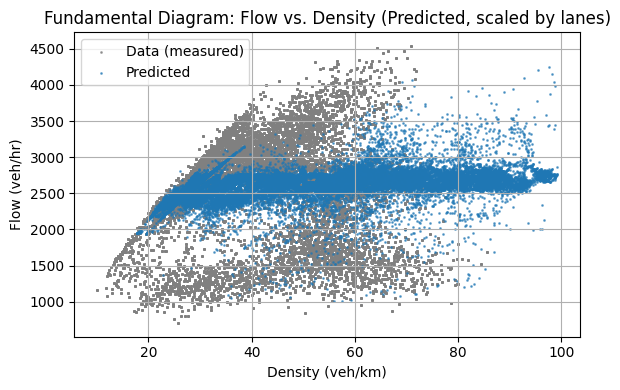

In [47]:
import matplotlib.pyplot as plt

# # Collect scaled predictions across all segments
all_rho_pred = rho_pred_array

print(all_rho_pred.shape)
all_v_pred = v_pred_array
all_q_pred = all_rho_pred * all_v_pred


# Stack predictions
all_rho_pred = np.hstack(all_rho_pred)
all_q_pred = np.hstack(all_q_pred)
all_v_pred = np.hstack(all_v_pred)

print(v_pred_array.shape)
print(v_hat.shape)
print(len(tau_array))

# assert np.all(v_pred_array[0,:] == v_hat[0,1:-1])
# assert np.all(v_pred_array[0,:] == v_hat[0,1:-1])
# Plot
plt.figure(figsize=(6, 4))
plt.scatter(rho_hat, q_hat, color="gray", alpha=0.7, s=1, label="Data (measured)")
plt.scatter(all_rho_pred, all_q_pred, alpha=0.6, s=1, label="Predicted")
plt.xlabel("Density (veh/km)")
plt.ylabel("Flow (veh/hr)")
plt.title("Fundamental Diagram: Flow vs. Density (Predicted, scaled by lanes)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

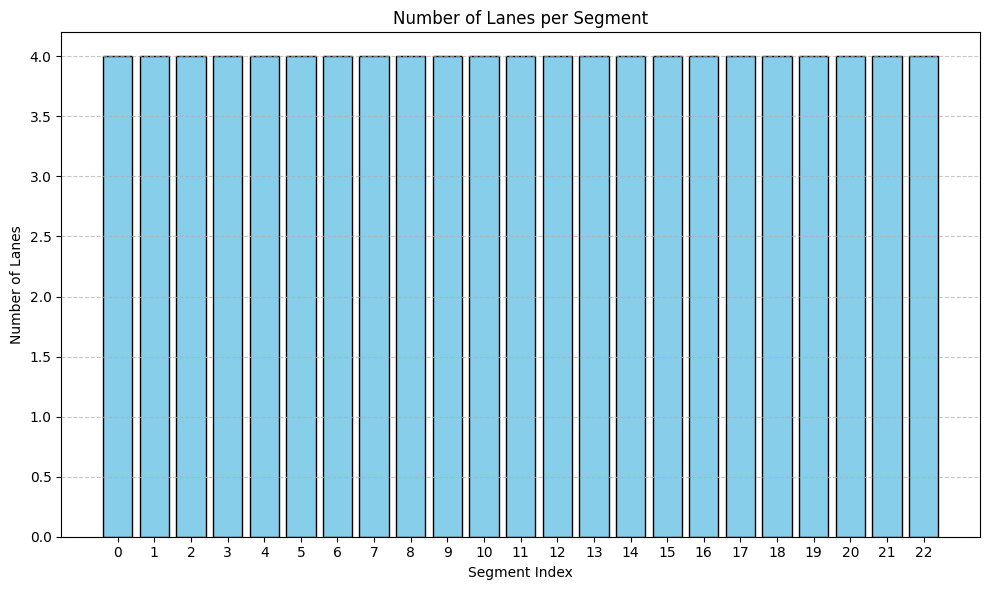

In [48]:
plt.figure(figsize=(10, 6))
plt.bar(
    np.arange(len(num_lanes_array)), num_lanes_array, color="skyblue", edgecolor="black"
)

plt.xlabel("Segment Index")
plt.ylabel("Number of Lanes")
plt.title("Number of Lanes per Segment")
plt.xticks(np.arange(len(num_lanes_array)))  # show all indices
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()

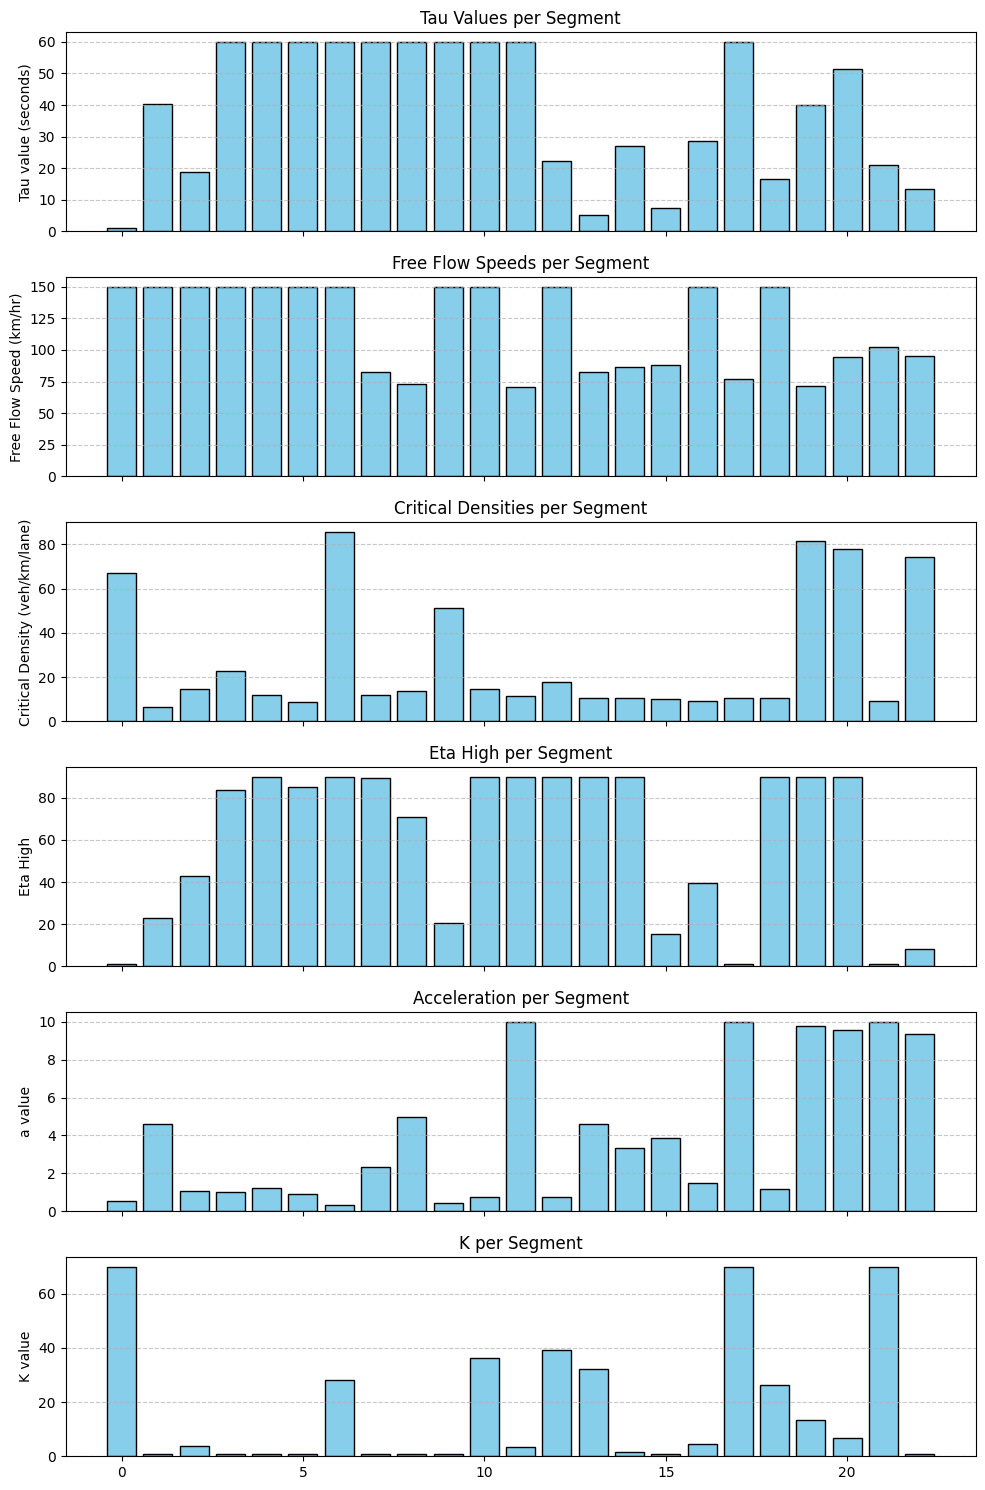

In [49]:
# Plot parameters in bar chart, show default value
fig, axes = plt.subplots(6, 1, figsize=(10, 15), sharex=True)
axes[0].bar(
    np.arange(len(tau_array)), tau_array*3600, color="skyblue", edgecolor="black"
)

axes[0].set_ylabel("Tau value (seconds)")
axes[0].set_title("Tau Values per Segment")
axes[0].grid(axis="y", linestyle="--", alpha=0.7)

axes[1].bar(
    np.arange(len(v_free_array)), v_free_array, color="skyblue", edgecolor="black"
)
axes[1].set_ylabel("Free Flow Speed (km/hr)")
axes[1].set_title("Free Flow Speeds per Segment")
axes[1].grid(axis="y", linestyle="--", alpha=0.7)

axes[2].bar(
    np.arange(len(rho_crit_array)), rho_crit_array, color="skyblue", edgecolor="black"
)
axes[2].set_ylabel("Critical Density (veh/km/lane)")
axes[2].set_title("Critical Densities per Segment")
axes[2].grid(axis="y", linestyle="--", alpha=0.7)

axes[3].bar(
    np.arange(len(eta_high_array)), eta_high_array, color="skyblue", edgecolor="black"
)
axes[3].set_ylabel("Eta High")
axes[3].set_title("Eta High per Segment")
axes[3].grid(axis="y", linestyle="--", alpha=0.7)

axes[4].bar(
    np.arange(len(a_array)), a_array, color="skyblue", edgecolor="black"
)
axes[4].set_ylabel("a value")
axes[4].set_title("Acceleration per Segment")
axes[4].grid(axis="y", linestyle="--", alpha=0.7)

axes[5].bar(
    np.arange(len(K_array)), K_array, color="skyblue", edgecolor="black"
)
axes[5].set_ylabel("K value")
axes[5].set_title("K per Segment")
axes[5].grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()

In [50]:
if include_ramping:
    plt.figure(figsize=(10, 6))
    plt.bar(
        np.arange(len(r_inflow_array)), r_inflow_array, color="skyblue", edgecolor="black"
    )

    plt.xlabel("Segment Index")
    plt.ylabel("Inflow")
    plt.title("Inflow per Segment")
    plt.xticks(np.arange(len(num_lanes_array)))  # show all indices
    plt.grid(axis="y", linestyle="--", alpha=0.7)

    plt.tight_layout()

In [51]:
if include_ramping:
    plt.figure(figsize=(10, 6))
    plt.bar(np.arange(len(beta_array)), beta_array, color="skyblue", edgecolor="black")

    plt.xlabel("Segment Index")
    plt.ylabel("Inflow")
    plt.title("Beta per Segment")
    plt.xticks(np.arange(len(num_lanes_array)))  # show all indices
    plt.grid(axis="y", linestyle="--", alpha=0.7)

    plt.tight_layout()

In [52]:
print(all_v_pred.shape)
q_array = rho_pred_array * v_pred_array
print("rho mape", mape(rho_hat[:, 1:-1], rho_pred_array))
print("q mape", mape(q_hat[:, 1:-1], q_array))
print("v mape", mape(v_hat[:, 1:-1], v_pred_array))
print("----------------")
print("rho rmse", rmse(rho_hat[:, 1:-1], rho_pred_array))
print("q rmse", rmse(q_hat[:, 1:-1], q_array))
print("v rmse", rmse(v_hat[:, 1:-1], v_pred_array))

(43240,)
rho mape 28.221995408419186
q mape 36.08423892653865
v mape 10.649856158220587
----------------
rho rmse 15.589645710717335
q rmse 818.2965166231594
v rmse 5.911174926549598


In [53]:
print("Simulating with calibrated parameters...")
# stop printing in scientific notation
np.set_printoptions(suppress=True)
# RESULTS_DIR = "calibration_results/test"
num_lanes_array = np.load(f"{RESULTS_DIR}/num_lanes.npy")

# Scale densities per lane for simulation
scaled_rho_hat = rho_hat[:, 1:-1] / np.array(num_lanes_array)


# if smoothing boundary conditions
print(num_lanes_array)
downstream_density = smooth_inflow(rho_hat[:, -1]) / num_lanes_array[-1]
data_inflow = smooth_inflow(q_hat[:, 0])
# downstream_density = rho_hat[:, -1] / num_lanes_array[-1]
# data_inflow = q_hat[:, 0]
# print(downstream_density[250:270])
# print(rho_hat[250:270, -1])

print(np.where(scaled_rho_hat < 0))
# Sim requires tuple of initial conditions: density, velocity, inflow, and queue
init_traffic_state = (scaled_rho_hat[0, :], v_hat[0, 1:-1], data_inflow[0], 0)
# print(RESULTS_DIR)

params = METANET_Params(path=RESULTS_DIR, num_segments=num_calibrated_segments).get_params()
print(params['beta'])
print(params['r'])
rho_sim, v_sim, _, tts_sim = run_metanet_sim(
    T, 
    l, 
    init_traffic_state,
    data_inflow,
    downstream_density,
    params,
    vsl_speeds=None,
    lanes={i: num_lanes_array[i] for i in range(num_calibrated_segments)},
    plotting=True,
    real_data=True
)

Simulating with calibrated parameters...
[4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4]
(array([], dtype=int64), array([], dtype=int64))
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Running sim for time steps 1880, segments 23


/Users/shreyaar/Desktop/macroscopic-sim-calibration/simulation_utils.py:31: RuntimeWarning: invalid value encountered in scalar power
  return v_free * np.exp(- (rho / p_crit) ** a / a)


In [54]:
good_params = METANET_Params(path=RESULTS_DIR, num_segments=num_calibrated_segments).get_params()
bad_params = METANET_Params(path='calibration_results', num_segments=num_calibrated_segments).get_params()
#check if params are different
print(bad_params['r'])
print(good_params['r'])
for key in bad_params:
    if isinstance(bad_params[key], dict):
        for subkey in bad_params[key]:
            if not np.array_equal(bad_params[key][subkey], good_params[key][subkey]):
                print(f"Parameter {key}[{subkey}] differs between bad and good params.")
    else:
        if not np.array_equal(bad_params[key], good_params[key]):
            print(f"Parameter {key} differs between bad and good params.")


[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Parameter tau differs between bad and good params.
Parameter K differs between bad and good params.
Parameter eta_high differs between bad and good params.
Parameter p_crit differs between bad and good params.
Parameter v_free differs between bad and good params.
Parameter a differs between bad and good params.
Parameter r differs between bad and good params.
Parameter beta differs between bad and good params.


Pred shape: (1880, 23)
True shape: (1880, 23)
Max true density: 85.63710064759843


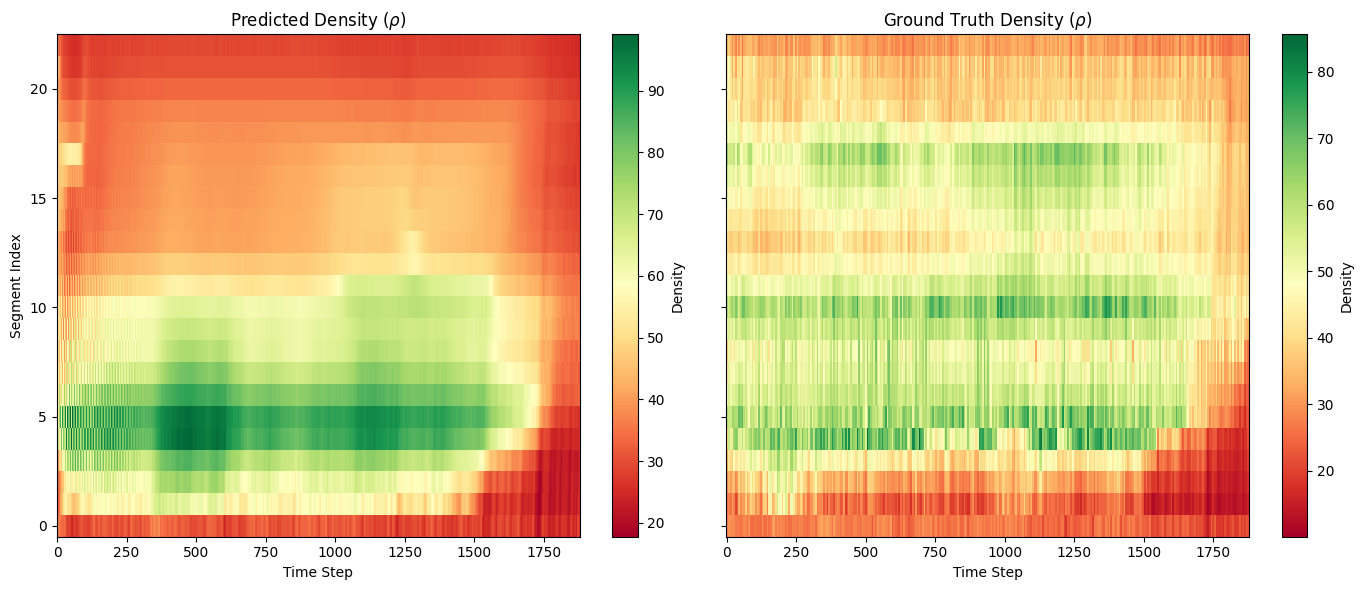

In [55]:
rho_plot_pred = rho_pred_array
rho_plot_true = rho_hat[:, 1:-1]

print("Pred shape:", rho_plot_pred.shape)
print("True shape:", rho_plot_true.shape)
print("Max true density:", np.max(rho_plot_true))

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# --- Prediction ---
im0 = axes[0].imshow(
    rho_plot_pred.T, aspect="auto", origin="lower", cmap="RdYlGn", interpolation="none"
)
axes[0].set_xlabel("Time Step")
axes[0].set_ylabel("Segment Index")
axes[0].set_title("Predicted Density ($\\rho$)")
fig.colorbar(im0, ax=axes[0], label="Density")

# --- Ground Truth ---
im1 = axes[1].imshow(
    rho_plot_true.T, aspect="auto", origin="lower", cmap="RdYlGn", interpolation="none"
)
axes[1].set_xlabel("Time Step")
axes[1].set_title("Ground Truth Density ($\\rho$)")
fig.colorbar(im1, ax=axes[1], label="Density")

plt.tight_layout()
plt.show()

[90.38581505 59.93282744 52.27526082 44.6176942  36.96012759 26.32842521
 30.5383441  34.74826298 38.95818187 44.89911915 50.84005644 56.81724578
 62.79443512 68.77162447 68.18006629 67.58850811 66.99694993 66.40539175
 65.74311062 65.08082949 69.15997204 73.23911459 84.63174351]
[88.43724899 88.38408387 69.2943553  47.52445371 28.2017605  29.46258675
 30.62013452 36.00340875 41.49017521 43.30946941 48.17728136 57.24308268
 60.87576851 56.16487016 61.31459933 49.43590925 60.38813369 60.76551637
 66.33414976 66.52102586 71.73235084 66.7926775  89.10072196]
Pred shape: (1880, 23)
True shape: (1880, 23)
Max true density: 117.34288869531251


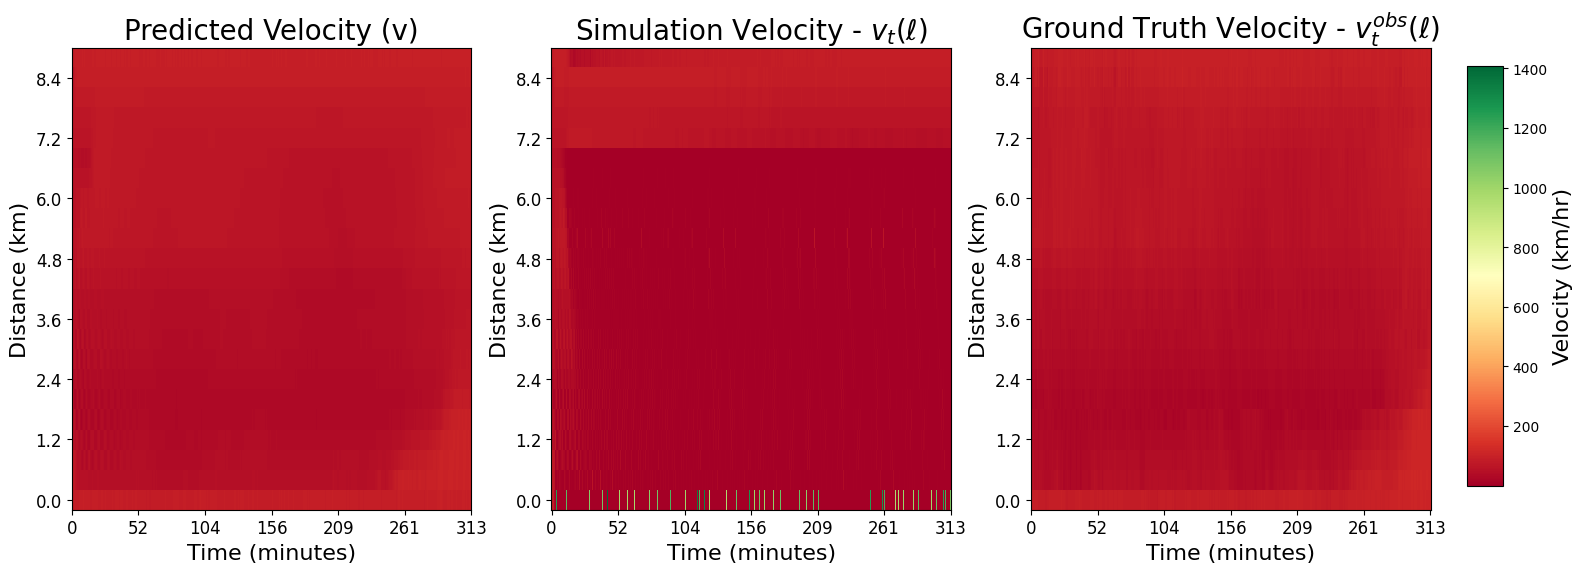

In [56]:
print(v_pred_array[0, :])
print(v_pred_array[1, :])
v_plot_pred = v_pred_array
v_plot_true = v_hat[:, 1:-1]

print("Pred shape:", v_plot_pred.shape)
print("True shape:", v_plot_true.shape)
print("Max true density:", np.max(v_plot_true))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- Compute common color scale ---
vmin = min(
    np.min(v_plot_pred),
    np.min(v_sim),
    np.min(v_plot_true),
)
vmax = max(
    np.max(v_plot_pred),
    np.max(v_sim),
    np.max(v_plot_true),
)

# --- Prediction ---
im0 = axes[0].imshow(
    v_plot_pred.T,
    aspect="auto",
    origin="lower",
    cmap="RdYlGn",
    interpolation="none",
    vmin=vmin,
    vmax=vmax,
)
axes[0].set_xlabel("Time Step")
axes[0].set_ylabel("Segment Index")
axes[0].set_title("Predicted Velocity (v)")

# --- Simulation ---
im1 = axes[1].imshow(
    v_sim.T,
    aspect="auto",
    origin="lower",
    cmap="RdYlGn",
    interpolation="none",
    vmin=vmin,
    vmax=vmax,
)
axes[1].set_xlabel("Time Step")
axes[1].set_title("Simulation Velocity - $v_t(\\ell)$", fontsize=20)

# --- Ground Truth ---
im2 = axes[2].imshow(
    v_plot_true.T,
    aspect="auto",
    origin="lower",
    cmap="RdYlGn",
    interpolation="none",
    vmin=vmin,
    vmax=vmax,
)
axes[2].set_xlabel("Time Step")
axes[2].set_title(
    "Ground Truth Velocity - $v^{obs}_t(\\ell)$",
    fontsize=20,
)

# ---- One shared colorbar in its own axis ----
# Make room on the right for the colorbar
fig.subplots_adjust(right=0.88)

# [left, bottom, width, height] in figure coordinates
cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im0, cax=cbar_ax)
cbar.set_label("Velocity (km/hr)", fontsize=16)

# Convert x label to minutes
for ax in axes:
    ax.set_xlabel("Time (minutes)")

# Convert x ticks to minutes
num_time_steps = v_plot_pred.shape[0]
time_step_indices = np.arange(0, num_time_steps, max(1, num_time_steps // 6))
time_step_labels = [f"{(i * T * 60):.0f}" for i in time_step_indices]
for ax in axes:
    ax.set_xticks(time_step_indices)
    ax.set_xticklabels(time_step_labels)

# Convert y axis to kilometers
for ax in axes:
    num_segments = v_plot_pred.shape[1]
    segment_indices = np.arange(0, num_segments, max(1, num_segments // 6))
    segment_labels = [f"{(i * l):.1f}" for i in segment_indices]
    ax.set_yticks(segment_indices)
    ax.set_yticklabels(segment_labels)
    ax.set_ylabel("Distance (km)")

# label font size
for ax in axes:
    ax.title.set_fontsize(20)
    ax.xaxis.label.set_fontsize(16)
    ax.yaxis.label.set_fontsize(16)
    ax.tick_params(axis='both', which='major', labelsize=12)    

plt.show()


In [26]:
np.save(f"{RESULTS_DIR}/v_sim.npy", v_sim)

In [27]:
print(all_v_pred.shape)
print("rho mape", mape(rho_hat[:, 1:-1], rho_sim[0:-1, :] * np.array(num_lanes_array)))
print("v mape", mape(v_hat[:, 1:-1], v_sim[0:-1, :]))
print("----------------")
print("rho rmse", rmse(rho_hat[:, 1:-1], rho_sim[0:-1, :] * np.array(num_lanes_array)))
print("v rmse", rmse(v_hat[:, 1:-1], v_sim[0:-1, :]))

(25920,)
rho mape 17.202282858259185
v mape 6.549339180466643
----------------
rho rmse 8.04922797202587
v rmse 6.278631877711845


In [28]:
print(mape(v_hat[:, 1:-1], v_sim[0:-1, :]))

6.549339180466643


/var/folders/kl/txwf6c7d73v3xczbyqm3trhw0000gn/T/ipykernel_2210/674838133.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


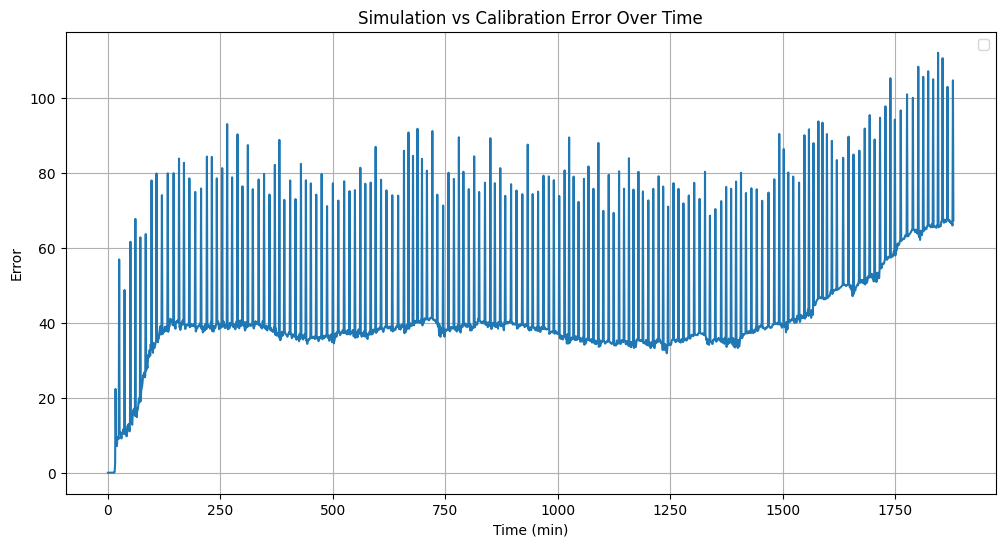

In [57]:
# plot error over time between prediction and simulation
plt.figure(figsize=(12, 6))
plt.plot(np.abs(v_plot_pred - v_sim[0:-1, :]).mean(axis=1))
plt.xlabel('Time (min)')
plt.ylabel('Error')
plt.title('Simulation vs Calibration Error Over Time')
plt.legend()
plt.grid()
plt.savefig(RESULTS_DIR + '/error_propogate_lanes_ramping.png')
plt.show()

/var/folders/kl/txwf6c7d73v3xczbyqm3trhw0000gn/T/ipykernel_2210/1933283574.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


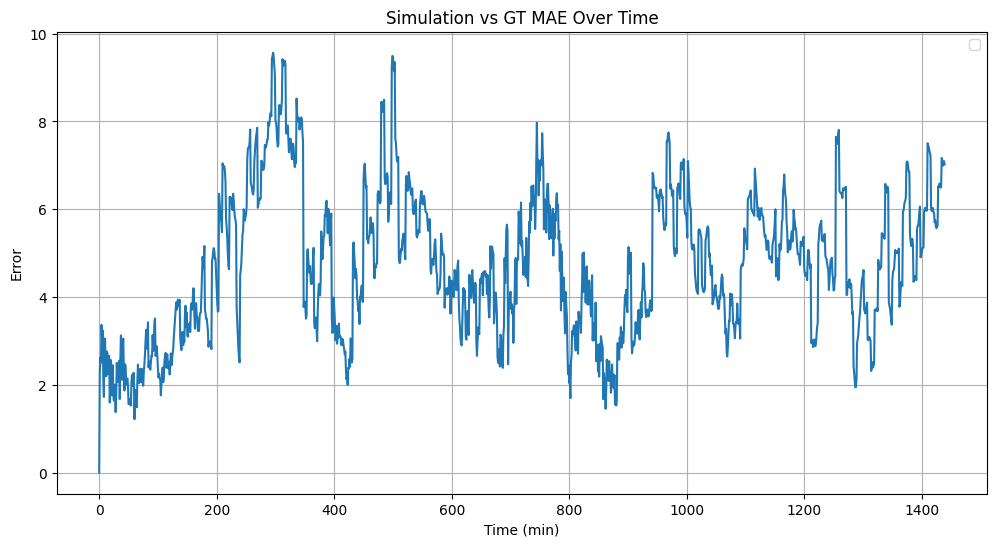

In [30]:
# plot error over time between prediction and simulation
plt.figure(figsize=(12, 6))
plt.plot(np.abs(v_hat[:, 1:-1] - v_sim[0:-1, :]).mean(axis=1))
plt.xlabel('Time (min)')
plt.ylabel('Error')
plt.title('Simulation vs GT MAE Over Time')
plt.legend()
plt.grid()
plt.savefig(RESULTS_DIR + '/error_propogate_lanes_ramping.png')
plt.show()

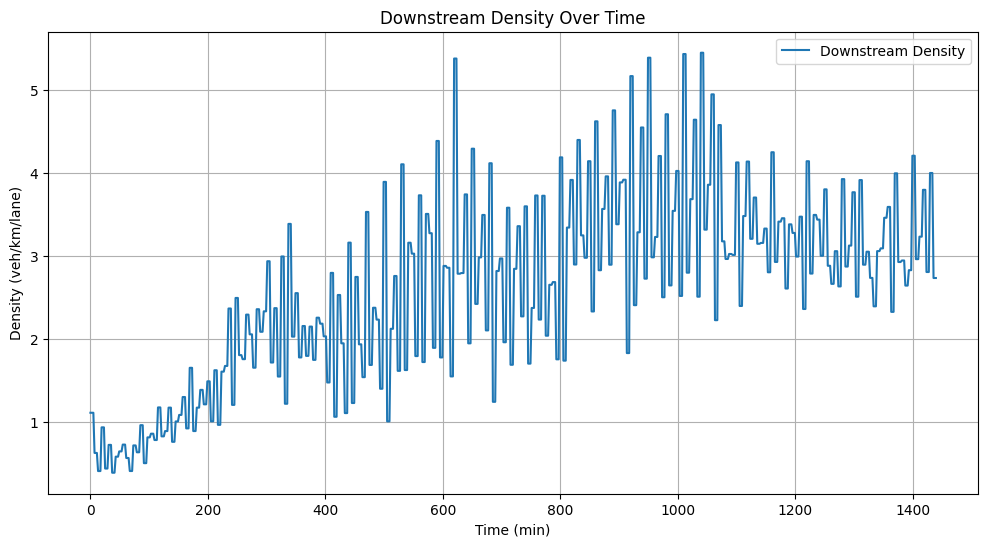

In [31]:
#plot downstream density over time and inflow over time
plt.figure(figsize=(12, 6))
plt.plot(downstream_density, label='Downstream Density')
plt.xlabel('Time (min)')
plt.ylabel('Density (veh/km/lane)')
plt.title('Downstream Density Over Time')
plt.legend()
plt.grid()
plt.show()



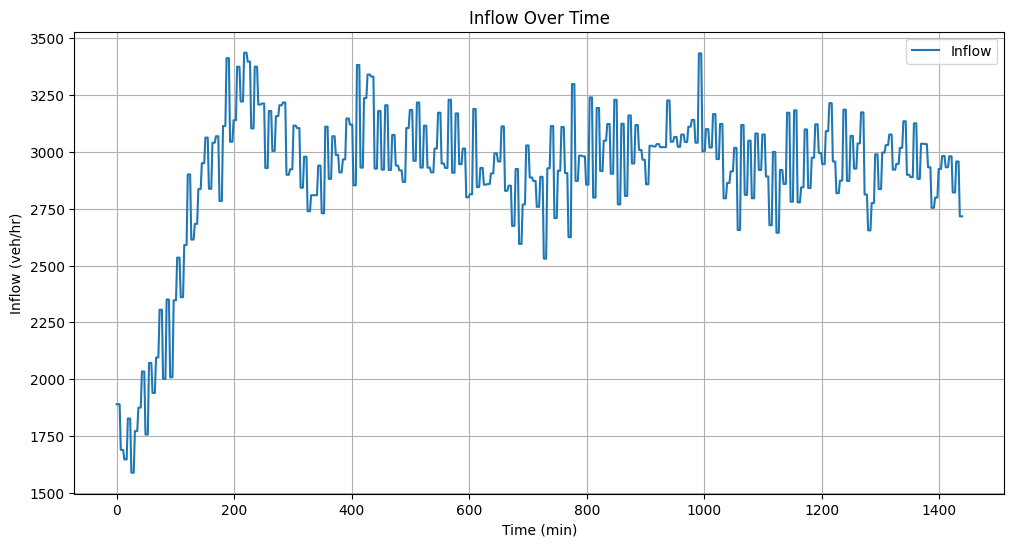

In [32]:
# Plot inflow over time
plt.figure(figsize=(12, 6))
plt.plot(data_inflow, label='Inflow')
plt.xlabel('Time (min)')
plt.ylabel('Inflow (veh/hr)')
plt.title('Inflow Over Time')
plt.legend()
plt.grid()
plt.show()

Pred shape: (360, 14)
True shape: (360, 14)
Max true density: 6749.992799999934


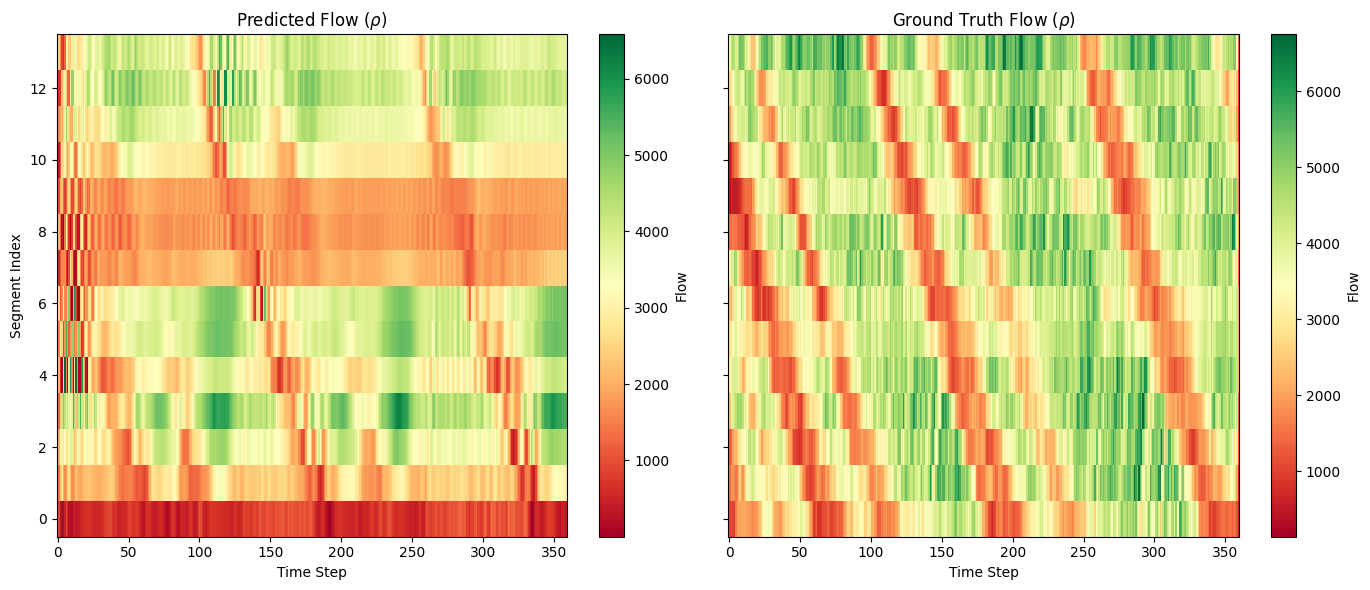

In [ ]:
rho_plot_pred = rho_pred_array * v_pred_array
rho_plot_true = q_hat[:, 1:-1]

print("Pred shape:", rho_plot_pred.shape)
print("True shape:", rho_plot_true.shape)
print("Max true density:", np.max(rho_plot_true))

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# --- Prediction ---
im0 = axes[0].imshow(
    rho_plot_pred.T, aspect="auto", origin="lower", cmap="RdYlGn", interpolation="none"
)
axes[0].set_xlabel("Time Step")
axes[0].set_ylabel("Segment Index")
axes[0].set_title("Predicted Flow ($\\rho$)")
fig.colorbar(im0, ax=axes[0], label="Flow")

# --- Ground Truth ---
im1 = axes[1].imshow(
    rho_plot_true.T, aspect="auto", origin="lower", cmap="RdYlGn", interpolation="none"
)
axes[1].set_xlabel("Time Step")
axes[1].set_title("Ground Truth Flow ($\\rho$)")
fig.colorbar(im1, ax=axes[1], label="Flow")

plt.tight_layout()
plt.show()

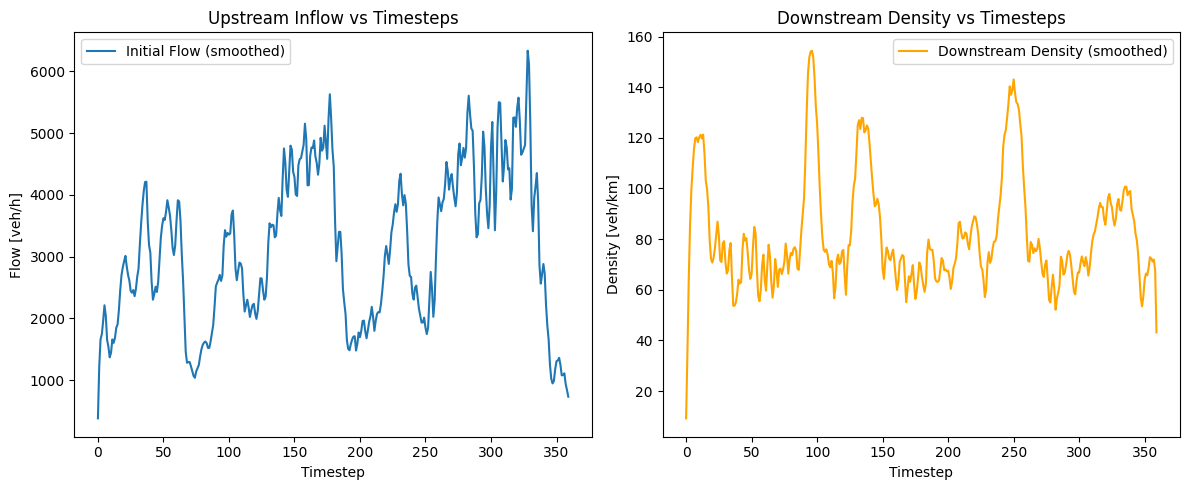

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def smooth_inflow(inflow, window_size=2):
    kernel = np.ones(window_size) / window_size
    smoothed = np.apply_along_axis(
        lambda m: np.convolve(m, kernel, mode="same"), axis=0, arr=inflow
    )
    return smoothed


# Example input arrays (replace with your real q_hat and rho_hat)
# timesteps = 100
# q_hat = np.random.uniform(500, 1000, size=(timesteps, 5))   # flow [veh/h]
# rho_hat = np.random.uniform(10, 50, size=(timesteps, 5))    # density [veh/km]

# Apply smoothing
initial_flow = smooth_inflow(q_hat[:, 0:1])  # upstream inflow
downstream_density = smooth_inflow(rho_hat[:, -1:])  # downstream density

# Plotting
plt.figure(figsize=(12, 5))

# Flow vs timesteps
plt.subplot(1, 2, 1)
plt.plot(initial_flow, label="Initial Flow (smoothed)")
plt.xlabel("Timestep")
plt.ylabel("Flow [veh/h]")
plt.title("Upstream Inflow vs Timesteps")
plt.legend()

# Density vs timesteps
plt.subplot(1, 2, 2)
plt.plot(downstream_density, color="orange", label="Downstream Density (smoothed)")
plt.xlabel("Timestep")
plt.ylabel("Density [veh/km]")
plt.title("Downstream Density vs Timesteps")
plt.legend()

plt.tight_layout()
plt.show()

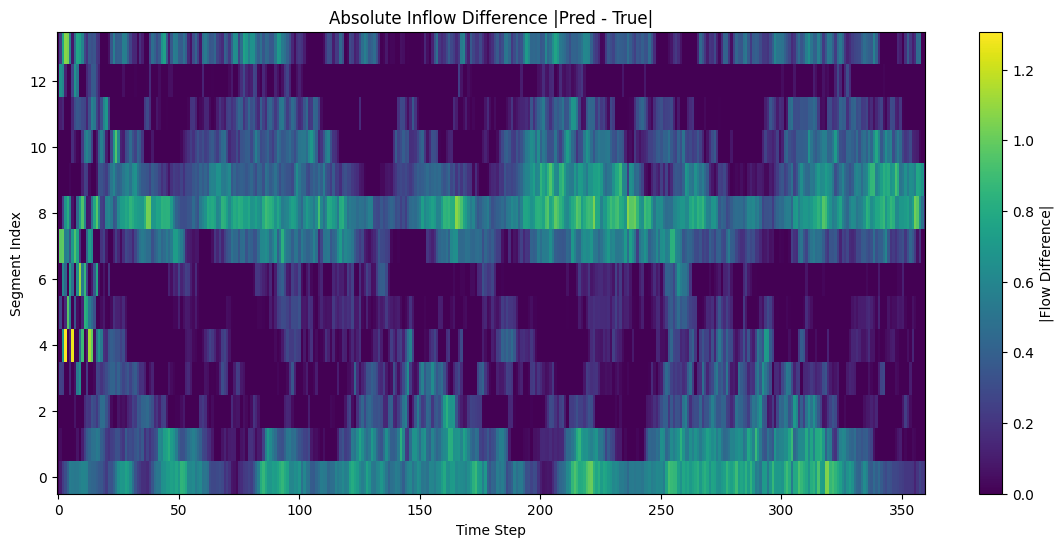

In [ ]:
def get_velocity_heatmap(v_hat, v_pred, q_hat, q_pred, rho_hat, rho_pred):
    shortened_v_hat = v_hat[:, 1:-1]
    shortened_rho_hat = rho_hat[:, 1:-1]
    shortened_q_hat = q_hat[:, 1:-1]
    # Determine some set of 3 scalars for each of q, rho, v to make a unified map
    v_diff = (shortened_v_hat - v_pred) / np.max(shortened_v_hat)
    rho_diff = (shortened_rho_hat - rho_pred) / np.max(shortened_rho_hat)
    q_diff = (shortened_q_hat - q_pred) / np.max(shortened_q_hat)

    diff = v_diff + rho_diff + q_diff
    fig, ax = plt.subplots(figsize=(14, 6))

    im = ax.imshow(
        diff.T,
        aspect="auto",
        origin="lower",
        cmap="viridis",
        interpolation="none",
        vmin=0,
    )
    ax.set_xlabel("Time Step")
    ax.set_ylabel("Segment Index")
    ax.set_title("Absolute Inflow Difference |Pred - True|")
    fig.colorbar(im, ax=ax, label="|Flow Difference|")
    plt.show()


get_velocity_heatmap(v_hat, v_pred_array, q_hat, q_array, rho_hat, rho_pred_array)